In [168]:
import numpy as np
import pandas as pd
import re

In [169]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [170]:
df = pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [171]:
df.shape

(3803, 17)

In [172]:
df.duplicated().sum()

np.int64(121)

In [173]:
# will work on -> areaWithType, additionalRoom, agePossession, furnishDetails, features
df.sample()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
3066,house,independent,sector 14,4.5,20000.0,2250.0,Carpet area: 2500 (232.26 sq.m.),5,5,1,not available,1.0,NaN,1 to 5 Year Old,"['Sheetla Mata Mandir', 'Hsbc bank ATM', 'Hdfc bank ATM', 'State bank of india ATM', 'Punjab national bank ATM', 'Nagpal Nursing Home Gurgaon', 'Kalyani Hospital Gurgaon', 'Kishor Clinic', 'Apollo Cradle Hospital Gurgaon', 'Saraswati Hospital Gurgaon', 'Sheetla Clinic', 'Dr. Babita Sharma', 'Nidhi Clinic', 'Children Hospital', 'Dr. Tomar Clinic', 'Jeevan Jyoti Hospital Gurgaon', 'Lotus Hospital Gurgaon', 'Sangwan Hospital Gurgaon', 'Mamta Hospital Gurgaon', 'Ahmed Hospital Multi Speciality', 'Jackson Hospital', 'Ahooja Eye and Dental Institute Hospital', 'Dr. Sandeep Chauhan', 'Sector-14 Market', 'Indian Oil', 'Standard chartered bank', 'Icici bank', 'Hdfc bank', 'Oriental bank of commerce', 'Karur vysay bank', 'Catholic syrian bank', 'State bank of india sbi', 'Punjab national bank', 'Rang Parivartan', 'Cafe Coffee Day', 'Dhabba', '32nd Milestone', 'Cafe Coffee Day', 'Ardor 29', 'ADDA', 'Gung the palace Korean restaurant', 'Walking Street', 'Tocpao', 'Spaghetti Kitchen & Bar', 'Swagath', 'Pizza Hut', 'Salvan Public School', 'Management Development Institute', 'Lieutenant Atul Kataria School', 'govt sec school']",NaN,NaN


#### areaWithType




* Superbuiltup area
* built-up area
* carpet area
* plot area


In [174]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
1907,1.00,750.0,Carpet area: 750 (69.68 sq.m.)
1975,1.30,1569.0,Super Built up area 1568(145.67 sq.m.)
1773,0.54,745.0,Carpet area: 745 (69.21 sq.m.)
1158,1.05,1895.0,Super Built up area 1895(176.05 sq.m.)
387,1.30,1880.0,Super Built up area 1880(174.66 sq.m.)


In [175]:
# Extracts the Super Built Up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [176]:
# Extracts the Built up / Carpet Area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [177]:
# Checks the unit of area and if given in sq.m then converts it to sq.ft
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [178]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [179]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3577,2.80,house,2250.0,Plot area 2250(209.03 sq.m.),NaN,NaN,NaN
513,0.24,flat,324.0,Carpet area: 324 (30.1 sq.m.),NaN,NaN,324.0
1329,0.42,flat,654.0,Super Built up area 623(57.88 sq.m.),623.0,NaN,NaN
1039,0.50,flat,800.0,Super Built up area 800(74.32 sq.m.)Carpet area: 605 sq.ft. (56.21 sq.m.),800.0,NaN,605.0
2897,2.35,flat,2033.0,Super Built up area 2033(188.87 sq.m.)Built Up area: 2030 sq.ft. (188.59 sq.m.)Carpet area: 1750 sq.ft. (162.58 sq.m.),2033.0,2030.0,1750.0


In [180]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [181]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1004,6.95,house,15479.0,Plot area 240(200.67 sq.m.)Built Up area: 2160 sq.yards (1806.04 sq.m.)Carpet area: 1720 sq.yards (1438.14 sq.m.),NaN,2160.0,1720.0
2640,8.75,house,3600.0,Plot area 400(334.45 sq.m.),NaN,NaN,NaN
2765,6.00,house,2430.0,Plot area 270(225.75 sq.m.),NaN,NaN,NaN
1221,8.25,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
233,0.50,house,540.0,Plot area 540(50.17 sq.m.),NaN,NaN,NaN


In [182]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,18
price_per_sqft,18
area,18
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [183]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [184]:
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1051,27.50,house,11286.0,Plot area 1254(1048.5 sq.m.),NaN,NaN,NaN
2280,10.85,house,3762.0,Plot area 418(349.5 sq.m.),NaN,NaN,NaN
1119,1.64,house,1620.0,Plot area 180(150.5 sq.m.),NaN,NaN,NaN
3782,1.70,house,2160.0,Plot area 240(200.67 sq.m.),NaN,NaN,NaN
1048,11.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN


In [185]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [186]:
# Extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [187]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [188]:
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1604,NaN,house,NaN,Plot area 520(434.79 sq.m.),NaN,520.0,NaN
2930,10.5,house,3618.0,Plot area 402(336.12 sq.m.),NaN,402.0,NaN
463,2.1,house,549.0,Plot area 61(51 sq.m.),NaN,61.0,NaN
2382,2.5,house,963.0,Plot area 107(89.47 sq.m.),NaN,107.0,NaN
880,0.9,house,785.0,Plot area 785(72.93 sq.m.),NaN,785.0,NaN


In [189]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [190]:
# Some areas for plots were in sq.yards and some in sq.m converting them to sq.ft
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [191]:
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3265,0.60,house,540.0,Plot area 60(50.17 sq.m.),NaN,540.0,NaN
1053,5.00,house,2250.0,Plot area 250(209.03 sq.m.),NaN,2250.0,NaN
1925,1.00,house,126.0,Plot area 126(11.71 sq.m.),NaN,126.0,NaN
2834,3.50,house,2610.0,Plot area 290(242.48 sq.m.),NaN,2610.0,NaN
3253,4.25,house,1620.0,Plot area 180(150.5 sq.m.),NaN,1620.0,NaN


In [192]:
df.update(all_nan_df)

In [193]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,18
price_per_sqft,18
area,18
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [194]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,house,ashok vihar phase iii extension,sector 3 phase 3 extension,0.40,8889.0,450.0,Plot area 50(41.81 sq.m.),7,4,3+,pooja room,4.0,NaN,0 to 1 Year Old,"['Palam Vihar Vyapar kendra', 'Palam triangle', 'Chintapurni Mandir', 'Sheetla Mata Mandir', 'Ram Mandir', 'State bank ATM', 'Jiya Clinic', 'Dr. Mittal Clinic', ""Dr. Anurag's Child Care Clinic"", 'Yashroop Medical Centre', 'Chirag Hospital Pvt. Ltd', 'Kalyan Hospital Gurgaon', 'R K Hospital Gurgaon', 'Sneh Hospital Gurgaon', 'Dr. Sindhu Clinic', 'Bhardwaj Hospital', 'Sarvodya Hospital', 'Jain Sant Phool Chand Ji Charitable Hospital', 'GH Gurgaon', 'Jeevan Jyoti Hospital Gurgaon', 'Dr. Hitesh Dawar', 'Gurgaon Eye Centre', 'Children Hospital', 'Dr. Tomar Clinic', 'Dr. Agya Ram Sharma Clinic', 'Sheetla Clinic', 'Prateek Nursing Home And Polyclinic', 'Nidhi Clinic', 'Dr. Babita Sharma', 'Kishor Clinic', 'Sparsh Hospital Gurgaon', 'Kr Dental Hub', 'Bhatnagar Maternity and Nursing Home', 'Axis bank', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'Big Cinemas', ""McDonald's"", 'Pizza Hut', 'Moti Mahal', 'Pind Baluchi', 'Cafe Coffee Day', 'Lieutenant Atul Kataria School', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['3 Fan', '15 Light', '1 Wardrobe', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",['Water Storage'],NaN,450.0,NaN
1,house,independent,sector 7,1.95,13542.0,1440.0,Plot area 160(133.78 sq.m.),2,2,2,not available,2.0,NaN,10+ Year Old,"['State bank ATM', 'Dr. Madan Clinic', 'Taneja Hospital', 'Dev Man Kathuria Clinic', 'Satyam Hospital Gurgaon', 'Pearl Dental Clinic', 'Chiranjiv Hospital', 'Swastik Maternity and Medical Centre', 'Shiv Mahima Patient Care Bureau', 'Shri Gobind Hospital', 'Navjeevan Hospital and Maternity Centre', 'Ankur Clinic and Maternity Home', 'Lal Superspeciality Hospital', 'Geeta Nursing Home Gurgaon', 'Dr. Ashok Jain', 'Bindal Clinic', 'My Care Clinic', 'M.S Hospital', 'Triveni Hospital Gurgaon', 'Ravi Clinic and Health Care Centre', 'Aryan Hospital', 'Tirath Ram Hospitals Pvt Ltd', 'D.R. Rajnis Gupta Clinic', 'Mangalam Hospital and Heart Centre Gurgaon', 'Sethi Hospital Gurgaon', 'Shubham Hospital Gurgaon', 'Pasricha Hospital and Maternity Home', 'Dr. Ajay S. Gupta Clinic', 'Nangia Hospital Ent and Maternity', 'Sparsh Hospital Gurgaon', 'Rama Hospital & Nursing Home', 'Bhatnagar Maternity and Nursing Home', 'Parashar Hospital', 'Gurgaon Eye Centre', 'Vinayak Hospital Gurgaon', 'Kathuria Hospital', 'Esic Hospital Gurugram', 'Kr Dental Hub', 'Gupta Hospital Gurgaon', 'Dr. Sarvejeet Singh', 'Centre For Sight Gurgaon New Railway Road', 'Kharbanda Maternity and Nursing Home', 'Kidney Clinic', 'State bank of india', 'Hdfc bank', 'Kotak bank', 'Indian bank', 'Pizza Hut', 'St. Michaels Sr. Sec. School', 'Dronacharya Government College']","['5 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN,NaN,1440.0,NaN
2,flat,Vatika City Homes3.9 ★,sector 83,1.08,6206.0,1740.0,Super Built up area 1740(161.65 sq.m.)Carpet area: 1350 sq.ft. (125.42 sq.m.),3,3,3,store room,6.0,South-West,1 to 5 Year Old,"['Kisan Mandi', 'Vatika City Centre', 'Manesar Toll Plaza', 'Sri Chaitanya School', 'Discovery Montessori Preschool', 'Vatika Lifestyle Nursery School', 'Global Healthcare Hospital', 'Badsa Ams Hospital', 'Miracles Apollo Hospital', 'Genesis Hospital', 'Inox Cinema', 'Football ground', 'IndianOil', 'IGL CNG Station', 'JSA Helipad']",NaN,

#### additionalRoom

In [195]:
df['additionalRoom'].value_counts()

,count
additionalRoom,
not available,1587
servant room,705
study room,250
others,225
pooja room,165
"study room,servant room",99
store room,99
"pooja room,servant room",82
"pooja room,study room,servant room,store room",72


In [196]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

In [197]:
# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [198]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
2346,"pooja room,study room,servant room,store room",1,1,1,1,0
1925,study room,1,0,0,0,0
3229,servant room,0,1,0,0,0
3483,servant room,0,1,0,0,0
925,not available,0,0,0,0,0


In [199]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,house,ashok vihar phase iii extension,sector 3 phase 3 extension,0.40,8889.0,450.0,Plot area 50(41.81 sq.m.),7,4,3+,pooja room,4.0,NaN,0 to 1 Year Old,"['Palam Vihar Vyapar kendra', 'Palam triangle', 'Chintapurni Mandir', 'Sheetla Mata Mandir', 'Ram Mandir', 'State bank ATM', 'Jiya Clinic', 'Dr. Mittal Clinic', ""Dr. Anurag's Child Care Clinic"", 'Yashroop Medical Centre', 'Chirag Hospital Pvt. Ltd', 'Kalyan Hospital Gurgaon', 'R K Hospital Gurgaon', 'Sneh Hospital Gurgaon', 'Dr. Sindhu Clinic', 'Bhardwaj Hospital', 'Sarvodya Hospital', 'Jain Sant Phool Chand Ji Charitable Hospital', 'GH Gurgaon', 'Jeevan Jyoti Hospital Gurgaon', 'Dr. Hitesh Dawar', 'Gurgaon Eye Centre', 'Children Hospital', 'Dr. Tomar Clinic', 'Dr. Agya Ram Sharma Clinic', 'Sheetla Clinic', 'Prateek Nursing Home And Polyclinic', 'Nidhi Clinic', 'Dr. Babita Sharma', 'Kishor Clinic', 'Sparsh Hospital Gurgaon', 'Kr Dental Hub', 'Bhatnagar Maternity and Nursing Home', 'Axis bank', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'Big Cinemas', ""McDonald's"", 'Pizza Hut', 'Moti Mahal', 'Pind Baluchi', 'Cafe Coffee Day', 'Lieutenant Atul Kataria School', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['3 Fan', '15 Light', '1 Wardrobe', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",['Water Storage'],NaN,450.0,NaN,0,0,0,1,0
1,house,independent,sector 7,1.95,13542.0,1440.0,Plot area 160(133.78 sq.m.),2,2,2,not available,2.0,NaN,10+ Year Old,"['State bank ATM', 'Dr. Madan Clinic', 'Taneja Hospital', 'Dev Man Kathuria Clinic', 'Satyam Hospital Gurgaon', 'Pearl Dental Clinic', 'Chiranjiv Hospital', 'Swastik Maternity and Medical Centre', 'Shiv Mahima Patient Care Bureau', 'Shri Gobind Hospital', 'Navjeevan Hospital and Maternity Centre', 'Ankur Clinic and Maternity Home', 'Lal Superspeciality Hospital', 'Geeta Nursing Home Gurgaon', 'Dr. Ashok Jain', 'Bindal Clinic', 'My Care Clinic', 'M.S Hospital', 'Triveni Hospital Gurgaon', 'Ravi Clinic and Health Care Centre', 'Aryan Hospital', 'Tirath Ram Hospitals Pvt Ltd', 'D.R. Rajnis Gupta Clinic', 'Mangalam Hospital and Heart Centre Gurgaon', 'Sethi Hospital Gurgaon', 'Shubham Hospital Gurgaon', 'Pasricha Hospital and Maternity Home', 'Dr. Ajay S. Gupta Clinic', 'Nangia Hospital Ent and Maternity', 'Sparsh Hospital Gurgaon', 'Rama Hospital & Nursing Home', 'Bhatnagar Maternity and Nursing Home', 'Parashar Hospital', 'Gurgaon Eye Centre', 'Vinayak Hospital Gurgaon', 'Kathuria Hospital', 'Esic Hospital Gurugram', 'Kr Dental Hub', 'Gupta Hospital Gurgaon', 'Dr. Sarvejeet Singh', 'Centre For Sight Gurgaon New Railway Road', 'Kharbanda Maternity and Nursing Home', 'Kidney Clinic', 'State bank of india', 'Hdfc bank', 'Kotak bank', 'Indian bank', 'Pizza Hut', 'St. Michaels Sr. Sec. School', 'Dronacharya Government College']","['5 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN,NaN,1440.0,NaN,0,0,0,0,0
2,flat,Vatika City Homes3.9 ★,sector 83,1.08,6206.0,1740.0,Super Built up area 1740(161.65 sq.m.)Carpet area: 1350 sq.ft. (125.42 sq.m.),3,3,3,store room,6.0,South-West,1 to 5 Year Old,"['Kisan Mandi', 'Vatika City Centre', 'Manesar Toll Plaza', 'Sri Chaitanya School', 'Discovery Montessori Preschool', 'Vatika Lifestyle Nursery School', 'Global Healthcare Hospital', 'Badsa Ams Hospital', 'Miracles Apollo Hospital', 'Genesis Hospital', 'Inox Cinema'

#### agePossession

In [200]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [201]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [202]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1676
New Property,626
Moderately Old,575
Undefined,484
Old Property,310
Under Construction,132


In [203]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,house,ashok vihar phase iii extension,sector 3 phase 3 extension,0.40,8889.0,450.0,Plot area 50(41.81 sq.m.),7,4,3+,pooja room,4.0,NaN,New Property,"['Palam Vihar Vyapar kendra', 'Palam triangle', 'Chintapurni Mandir', 'Sheetla Mata Mandir', 'Ram Mandir', 'State bank ATM', 'Jiya Clinic', 'Dr. Mittal Clinic', ""Dr. Anurag's Child Care Clinic"", 'Yashroop Medical Centre', 'Chirag Hospital Pvt. Ltd', 'Kalyan Hospital Gurgaon', 'R K Hospital Gurgaon', 'Sneh Hospital Gurgaon', 'Dr. Sindhu Clinic', 'Bhardwaj Hospital', 'Sarvodya Hospital', 'Jain Sant Phool Chand Ji Charitable Hospital', 'GH Gurgaon', 'Jeevan Jyoti Hospital Gurgaon', 'Dr. Hitesh Dawar', 'Gurgaon Eye Centre', 'Children Hospital', 'Dr. Tomar Clinic', 'Dr. Agya Ram Sharma Clinic', 'Sheetla Clinic', 'Prateek Nursing Home And Polyclinic', 'Nidhi Clinic', 'Dr. Babita Sharma', 'Kishor Clinic', 'Sparsh Hospital Gurgaon', 'Kr Dental Hub', 'Bhatnagar Maternity and Nursing Home', 'Axis bank', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'Big Cinemas', ""McDonald's"", 'Pizza Hut', 'Moti Mahal', 'Pind Baluchi', 'Cafe Coffee Day', 'Lieutenant Atul Kataria School', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['3 Fan', '15 Light', '1 Wardrobe', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",['Water Storage'],NaN,450.0,NaN,0,0,0,1,0
1,house,independent,sector 7,1.95,13542.0,1440.0,Plot area 160(133.78 sq.m.),2,2,2,not available,2.0,NaN,Old Property,"['State bank ATM', 'Dr. Madan Clinic', 'Taneja Hospital', 'Dev Man Kathuria Clinic', 'Satyam Hospital Gurgaon', 'Pearl Dental Clinic', 'Chiranjiv Hospital', 'Swastik Maternity and Medical Centre', 'Shiv Mahima Patient Care Bureau', 'Shri Gobind Hospital', 'Navjeevan Hospital and Maternity Centre', 'Ankur Clinic and Maternity Home', 'Lal Superspeciality Hospital', 'Geeta Nursing Home Gurgaon', 'Dr. Ashok Jain', 'Bindal Clinic', 'My Care Clinic', 'M.S Hospital', 'Triveni Hospital Gurgaon', 'Ravi Clinic and Health Care Centre', 'Aryan Hospital', 'Tirath Ram Hospitals Pvt Ltd', 'D.R. Rajnis Gupta Clinic', 'Mangalam Hospital and Heart Centre Gurgaon', 'Sethi Hospital Gurgaon', 'Shubham Hospital Gurgaon', 'Pasricha Hospital and Maternity Home', 'Dr. Ajay S. Gupta Clinic', 'Nangia Hospital Ent and Maternity', 'Sparsh Hospital Gurgaon', 'Rama Hospital & Nursing Home', 'Bhatnagar Maternity and Nursing Home', 'Parashar Hospital', 'Gurgaon Eye Centre', 'Vinayak Hospital Gurgaon', 'Kathuria Hospital', 'Esic Hospital Gurugram', 'Kr Dental Hub', 'Gupta Hospital Gurgaon', 'Dr. Sarvejeet Singh', 'Centre For Sight Gurgaon New Railway Road', 'Kharbanda Maternity and Nursing Home', 'Kidney Clinic', 'State bank of india', 'Hdfc bank', 'Kotak bank', 'Indian bank', 'Pizza Hut', 'St. Michaels Sr. Sec. School', 'Dronacharya Government College']","['5 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN,NaN,1440.0,NaN,0,0,0,0,0
2,flat,Vatika City Homes3.9 ★,sector 83,1.08,6206.0,1740.0,Super Built up area 1740(161.65 sq.m.)Carpet area: 1350 sq.ft. (125.42 sq.m.),3,3,3,store room,6.0,South-West,Relatively New,"['Kisan Mandi', 'Vatika City Centre', 'Manesar Toll Plaza', 'Sri Chaitanya School', 'Discovery Montessori Preschool', 'Vatika Lifestyle Nursery School', 'Global Healthcare Hospital', 'Badsa Ams Hospital', 'Miracles Apollo Hospital', 'Genesis Hospital', 'Inox Cinema', 'F

#### furnishDetails

In [204]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
3609,NaN,"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'False Ceiling Lighting', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Swimming Pool', 'Park', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
2445,"['7 Fan', '4 Geyser', '6 Light', '5 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
2264,"['3 Fan', '1 Exhaust Fan', '10 Light', '2 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
2062,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",NaN
867,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",NaN


In [205]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(rf"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [206]:
furnishings_df.shape

(3803, 19)

In [207]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

/tmp/ipykernel_1542/114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [208]:
furnishings_df.sample(5)

,AC,Chimney,Exhaust Fan,Bed,Wardrobe,Stove,Modular Kitchen,Sofa,TV,Dining Table,Microwave,Geyser,Water Purifier,Light,Fridge,Curtains,Washing Machine,Fan
2346,5,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0
2260,5,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2537,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,4
1419,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1189,5,1,1,0,3,0,1,0,0,0,0,3,0,10,0,0,0,5


In [209]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [210]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [211]:
wcss_reduced = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
  kmeans.fit(scaled_data)
  wcss_reduced.append(kmeans.inertia_)

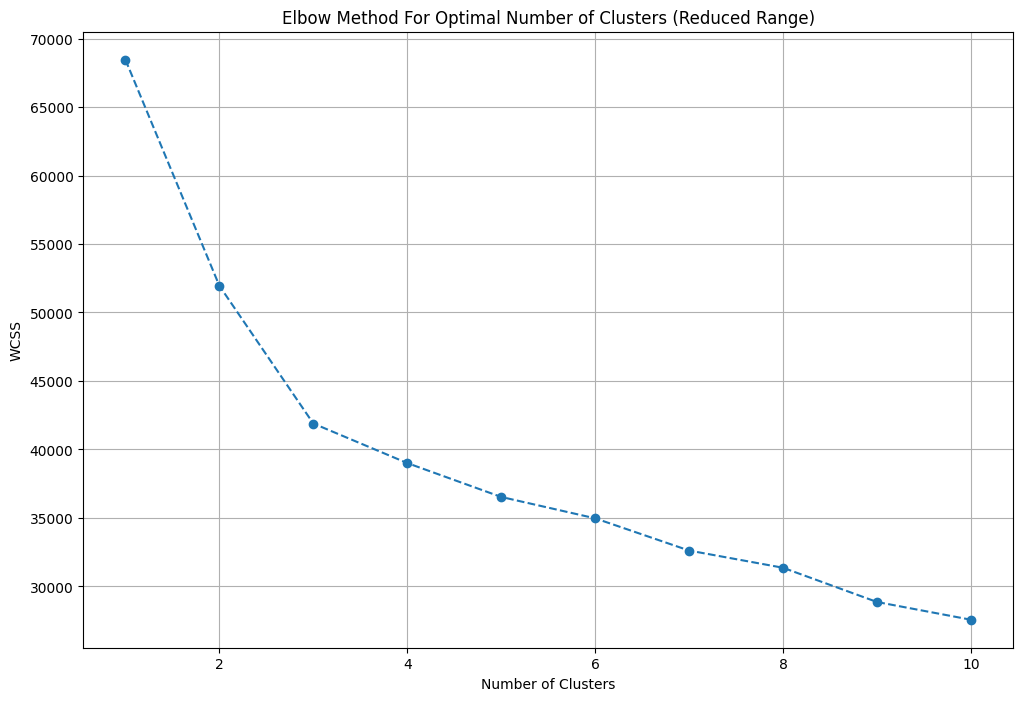

In [212]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1, 11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [213]:
n_clusters = 3
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [214]:
df = df.iloc[:,:-18]

In [215]:
df['furnishing_type'] = cluster_assignments

In [216]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
1224,"['5 Fan', '1 Fridge', '1 Exhaust Fan', '3 Geyser', '1 Stove', '14 Light', '5 AC', '1 Chimney', '1 Curtains', '1 Modular Kitchen', '1 Sofa', '1 Microwave', '1 Washing Machine', 'No Bed', 'No Dining Table', 'No TV', 'No Wardrobe', 'No Water Purifier']",2
510,"['1 Water Purifier', '3 Fan', '1 Fridge', '1 Dining Table', '3 Geyser', '1 Stove', '6 Light', '1 Curtains', '1 Chimney', '1 Modular Kitchen', '3 AC', '2 TV', '2 Bed', '3 Wardrobe', '1 Sofa', '1 Washing Machine', 'No Exhaust Fan', 'No Microwave']",2
1692,"['1 Wardrobe', '4 Fan', '1 Exhaust Fan', '6 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",1
73,NaN,0
1573,NaN,0


#### features

In [217]:
df[['society','features']].sample(5)

,society,features
1870,dlf new town heights,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Water purifier', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Recently Renovated', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Spacious Interiors', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
175,independent,NaN
2635,ansal sushant lok plots,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Waste Disposal', 'Rain Water Harvesting']"
65,BPTP Terra3.8 ★,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
2440,Signature Global Park4.0 ★,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [218]:
df['features'].isnull().sum()

np.int64(635)

In [219]:
import pandas as pd
app_df = pd.read_csv('/content/real_estate_data - real_estate_data.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [220]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [221]:
temp_df = df[df['features'].isnull()]

In [222]:
temp_df.shape

(635, 26)

In [223]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [224]:
df.loc[temp_df.index,'features'] = x.values

In [225]:
df['features'].isnull().sum()

np.int64(618)

In [226]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [227]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [228]:
features_binary_df.sample(5)

,24/7 Power Backup,24x7 Security,ATM,Aerobics Centre,Airy Rooms,Amphitheatre,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Creche/Day care,Cricket Pitch,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Landscape Garden,Laundry,Lawn Tennis Court,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Natural Light,No open drainage around,Park,Pergola,Piped Gas,Piped-gas,Power Back-up,Private Garden / Terrace,Property Staff,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Terrace Garden,Video Door Security,Visitor Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
599,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0,0
1193,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,1,1,0,0,1,0,1,0,1,0,1,0,0,0,0,0,1,1,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,1,1,0,0,0
2311,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,0,0,1,0,1,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,1,0,0,0
2767,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,0,1,0,0
2522,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [229]:
features_binary_df.shape

(3803, 96)

In [230]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

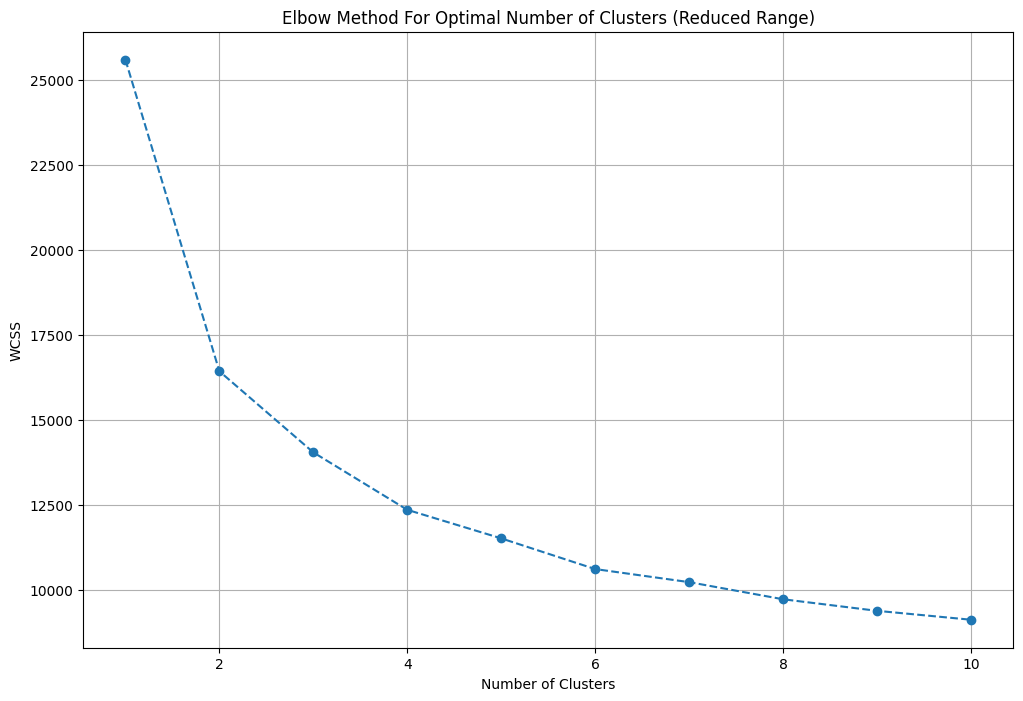

In [231]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
# elbow method -> 2 cluster i.e luxury, budget
# but needed threee (luxury, semi-luxury, budget)
# using another apporach for that
# using luxury score -> assigning each facility a score

In [248]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}

modified_weights = {
    feature: weight
    for feature, weight in weights.items()
    if feature in features_binary_df.columns
}

In [250]:
luxury_score = (
    features_binary_df[list(modified_weights.keys())]
    .multiply(list(modified_weights.values()))
    .sum(axis=1)
)

In [251]:
df['luxury_score'] = luxury_score

In [263]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [264]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1541,flat,DLF Regal Gardens3.9 ★,sector 90,1.76,7945.0,2215.0,Super Built up area 2215(205.78 sq.m.)Built Up area: 2020 sq.ft. (187.66 sq.m.)Carpet area: 1670 sq.ft. (155.15 sq.m.),4,4,3+,8.0,North,Relatively New,2215.0,2020.0,1670.0,0,0,0,0,0,1,135
65,flat,BPTP Terra3.8 ★,sector 37d,1.50,8255.0,1817.0,Super Built up area 1811(168.25 sq.m.)Carpet area: 1560 sq.ft. (144.93 sq.m.),3,3,3,12.0,South-West,Relatively New,1811.0,NaN,1560.0,0,0,0,0,1,0,49
1861,flat,SBTL Caladium,sector 109,1.26,6542.0,1926.0,Super Built up area 1880(174.66 sq.m.),3,2,3,8.0,North-East,Relatively New,1880.0,NaN,NaN,0,0,0,0,0,0,103
520,flat,Antriksh Heights3.7 ★,sector 84,0.88,4821.0,1825.0,Super Built up area 1825(169.55 sq.m.),3,3,3,16.0,NaN,Relatively New,1825.0,NaN,NaN,0,0,0,1,0,0,67
8,flat,MVN Athens3.7 ★,sohna road,0.21,4666.0,450.0,Carpet area: 450 (41.81 sq.m.),1,1,1,11.0,NaN,New Property,NaN,NaN,450.0,0,0,0,0,0,0,16


In [265]:
df.shape

(3803, 23)

In [266]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)